# CIFAR-10 — NSI Dynamic Brain
**Neuron Strain Index**: per-neuron freeze + proportional sprout.
Experiments: `tau_high` percentile vs absolute · output vs hidden grad tracking.

In [66]:
import subprocess
subprocess.run(["pip", "install", "-q", "datasets"])

from datasets import load_dataset
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test  = load_dataset("uoft-cs/cifar10", split="test")

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)

def hf_to_tensors(ds):
    imgs   = torch.tensor(np.array([np.array(x) for x in ds['img']])).float()/255.0
    imgs   = imgs.permute(0,3,1,2)
    imgs   = (imgs - mean) / std
    imgs   = imgs.reshape(imgs.size(0), -1)
    labels = torch.tensor(ds['label'])
    return imgs, labels

X_tr, y_tr = hf_to_tensors(hf_train)
X_te, y_te = hf_to_tensors(hf_test)

def get_task(X, y, a, b, n=2000):
    idx  = (y==a)|(y==b)
    X2,y2 = X[idx], y[idx]
    p = torch.randperm(X2.size(0))[:n]
    return X2[p], y2[p]

tasks_train = [get_task(X_tr,y_tr, i*2,i*2+1, 2000) for i in range(5)]
tasks_test  = [get_task(X_te,y_te, i*2,i*2+1,  500) for i in range(5)]

task_names = ['T1:Airplane/Auto','T2:Bird/Cat','T3:Deer/Dog',
              'T4:Frog/Horse','T5:Ship/Truck']
print("Data ready.")


Using device: cuda
Data ready.


## Architecture

In [67]:
def evaluate(net, tasks_test, idx):
    net.eval()
    accs = []
    with torch.no_grad():
        for i in range(idx+1):
            Xt, yt = tasks_test[i]
            Xt, yt = Xt.to(device), yt.to(device)
            pred = net(Xt)
            mask = torch.ones_like(pred, dtype=torch.bool)
            mask[:, [i*2, i*2+1]] = False
            pred[mask] = -float('inf')
            accs.append((pred.argmax(1)==yt).float().mean().item())
    net.train()
    return accs


class DynamicBrain(nn.Module):
    def __init__(self, input_dim=3072, output_dim=10, seed_neurons=10, k_frozen=10, k_plastic=5):
        super().__init__()
        self.input_dim  = input_dim
        self.output_dim = output_dim
        self.k_frozen   = k_frozen
        self.k_plastic  = k_plastic
        n = seed_neurons

        self.hidden_W = nn.Parameter(torch.randn(n, input_dim) * 0.1)
        self.hidden_b = nn.Parameter(torch.zeros(n))
        self.out_W    = nn.Parameter(torch.zeros(output_dim, n))
        self.out_b    = nn.Parameter(torch.zeros(output_dim))

        self.neuron_states  = ['PLASTIC'] * n
        self.active_neurons = n

    def forward(self, x):
        h = F.linear(x, self.hidden_W, self.hidden_b)
        
        frozen_idx  = [i for i, s in enumerate(self.neuron_states) if s == 'FROZEN']
        plastic_idx = [i for i, s in enumerate(self.neuron_states) if s == 'PLASTIC']
        
        mask = torch.zeros_like(h)
        
        if frozen_idx:
            kf = min(self.k_frozen, len(frozen_idx))
            if kf > 0:
                hf = h[:, frozen_idx]
                _, top_idx = hf.topk(kf, dim=1)
                # Scatter 1.0 into mask at the correct global indices
                global_top = torch.tensor(frozen_idx, device=h.device)[top_idx]
                mask.scatter_(1, global_top, 1.0)
                
        if plastic_idx:
            kp = min(self.k_plastic, len(plastic_idx))
            if kp > 0:
                hp = h[:, plastic_idx]
                _, top_idx = hp.topk(kp, dim=1)
                global_top = torch.tensor(plastic_idx, device=h.device)[top_idx]
                mask.scatter_(1, global_top, 1.0)
                
        h = F.relu(h * mask)
        return F.linear(h, self.out_W, self.out_b)

    def zero_frozen_grads(self):
        frozen = [i for i,s in enumerate(self.neuron_states) if s=='FROZEN']
        if frozen:
            if self.hidden_W.grad is not None:
                self.hidden_W.grad[frozen, :] = 0
                self.hidden_b.grad[frozen]    = 0
            # REMOVED out_W.grad zeroing here.
            # We WANT new classes to learn to use frozen features!
            # Past classes are already protected by active-class masking.

    def grow_and_freeze(self, freeze_indices, num_new):
        for i in freeze_indices:
            self.neuron_states[i] = 'FROZEN'
        if num_new <= 0:
            return
        self.active_neurons += num_new
        self.neuron_states.extend(['PLASTIC'] * num_new)
        with torch.no_grad():
            dev = self.out_b.device
            hW = torch.randn(num_new, self.input_dim,  device=dev) * 0.1
            hb = torch.zeros(num_new,                  device=dev)
            oW = torch.zeros(self.output_dim, num_new, device=dev)  # ZERO init prevents corrupting past classes
            self.hidden_W = nn.Parameter(torch.cat([self.hidden_W, hW], 0))
            self.hidden_b = nn.Parameter(torch.cat([self.hidden_b, hb], 0))
            self.out_W    = nn.Parameter(torch.cat([self.out_W,    oW], 1))

print("DynamicBrain defined.")


DynamicBrain defined.


## NeuronHealthMonitor

In [68]:
class NeuronHealthMonitor:
    # Tracks per-neuron health via Neuron Strain Index (NSI).
    #
    # Three EMAs per neuron:
    #   grad_mag[n]     = EMA of ||grad_hidden_W[n]||   (demand)
    #   out_grad_mag[n] = EMA of ||grad_out_W[:,n]||    (output demand)
    #   contribution[n] = EMA of (grad_n . delta_w_n)   (SI: is it helping?)
    #
    # Freeze conditions (after min_age batches, checked every check_interval):
    #   CONVERGED  : grad_mag[n] < tau_low              for patience checks
    #   STRUGGLING : grad_mag[n] > tau_high AND
    #                contribution[n] <= tau_contrib      for patience checks
    #
    # tau_high_mode:
    #   'percentile' -> self-calibrating, adapts as network grows
    #   'absolute'   -> fixed; calibrate from diagnostic cell
    def __init__(self, num_neurons, device='cpu',
                 alpha=0.05,
                 check_interval=20, patience=3, min_age=40,
                 tau_low=0.001,
                 tau_high_mode='percentile',
                 tau_high_pct=0.70,
                 tau_high_abs=None,
                 tau_conflict=0.5,
                 track_output_grads=True):

        self.device           = device
        self.alpha            = alpha
        self.check_interval   = check_interval
        self.patience         = patience
        self.min_age          = min_age
        self.tau_low          = tau_low
        self.tau_high_mode    = tau_high_mode
        self.tau_high_pct     = tau_high_pct
        self.tau_high_abs     = tau_high_abs
        self.tau_conflict      = tau_conflict
        self.track_output_grads = track_output_grads

        self._alloc(num_neurons)
        self.w_prev   = None
        self.batch_no = 0

        # Diagnostics log (filled during training for analysis)
        self.log = []   # list of dicts, one per check_interval

    def _alloc(self, n):
        d = self.device
        self.grad_mag      = torch.zeros(n, device=d)
        self.out_grad_mag  = torch.zeros(n, device=d)
        self.conflict      = torch.zeros(n, device=d)
        self.grad_vec      = None
        self.age           = torch.zeros(n, dtype=torch.long, device=d)
        self.conv_count    = torch.zeros(n, dtype=torch.long, device=d)
        self.str_count     = torch.zeros(n, dtype=torch.long, device=d)
        self.n             = n

    def expand(self, num_new):
        d = self.device
        def _cat(t, m=None):
            if m is None:
                return torch.cat([t, torch.zeros(num_new, device=d)])
            return torch.cat([t, torch.zeros(num_new, dtype=m, device=d)])
        self.grad_mag     = _cat(self.grad_mag)
        self.out_grad_mag = _cat(self.out_grad_mag)
        self.conflict     = _cat(self.conflict)
        if self.grad_vec is not None:
            self.grad_vec = torch.cat([self.grad_vec, torch.zeros(num_new, self.grad_vec.size(1), device=d)])
        self.age          = _cat(self.age,        torch.long)
        self.conv_count   = _cat(self.conv_count, torch.long)
        self.str_count    = _cat(self.str_count,  torch.long)
        self.n           += num_new

    def pre_step(self, net):
        # Call BEFORE optimizer.step() to snapshot weights.
        self.w_prev = net.hidden_W.data.clone()

    def post_step(self, net, hidden_grad, out_grad=None):
        # Call AFTER optimizer.step() to update EMAs.
        delta = net.hidden_W.data - self.w_prev   # actual weight movement
        a     = self.alpha

        for n in range(self.n):
            if net.neuron_states[n] == 'FROZEN':
                continue
            gn     = hidden_grad[n]
            dn     = delta[n]
            gm     = gn.norm().item()
            if self.grad_vec is None:
                self.grad_vec = torch.zeros_like(hidden_grad)
                
            self.grad_mag[n] = (1-a)*self.grad_mag[n] + a*gm
            self.grad_vec[n] = (1-a)*self.grad_vec[n] + a*gn
            
            # Conflict Index: 1.0 - (||ema_grad_vec|| / ema_grad_mag)
            # High conflict (~1.0) means gradients are oscillating/pulling in different directions
            # Low conflict (~0.0) means gradients point in a consistent direction
            vec_mag = self.grad_vec[n].norm().item()
            conf = 1.0 - (vec_mag / (self.grad_mag[n].item() + 1e-8))
            self.conflict[n] = conf

            if self.track_output_grads and out_grad is not None:
                ogm = out_grad[:, n].norm().item()
                self.out_grad_mag[n] = (1-a)*self.out_grad_mag[n] + a*ogm

            self.age[n] += 1
        self.batch_no += 1

    def _tau_high(self, plastic_ids):
        if self.tau_high_mode == 'absolute':
            return self.tau_high_abs
        # percentile mode: self-calibrating
        if len(plastic_ids) < 2:
            return self.grad_mag[plastic_ids].max().item() if plastic_ids else 1e9
        gm = self.grad_mag[plastic_ids]
        return torch.quantile(gm, self.tau_high_pct).item()

    def check_health(self, net):
        # Called every check_interval batches.
        # Returns (freeze_indices, n_sprout, log_dict).

        plastic = [i for i,s in enumerate(net.neuron_states)
                   if s == 'PLASTIC' and self.age[i] >= self.min_age]
        to_freeze, n_sprout = [], 0

        tau_h = self._tau_high(plastic)

        for n in plastic:
            gm   = self.grad_mag[n].item()
            conf = self.conflict[n].item()
            ogm  = self.out_grad_mag[n].item()

            converged   = gm < self.tau_low
            struggling  = gm > tau_h and conf >= self.tau_conflict

            if converged:
                self.conv_count[n] += 1
                self.str_count[n]   = 0
                if self.conv_count[n] >= self.patience:
                    to_freeze.append(n)          # converged: freeze, no sprout
            elif struggling:
                self.str_count[n] += 1
                self.conv_count[n]  = 0
                if self.str_count[n] >= self.patience:
                    to_freeze.append(n)          # struggling: freeze + sprout
                    n_sprout += 1
            else:
                self.conv_count[n] = 0
                self.str_count[n]  = 0

        # Diagnostic snapshot
        snap = {
            'batch': self.batch_no,
            'tau_high': tau_h,
            'tau_high_mode': self.tau_high_mode,
            'n_plastic': len(plastic),
            'n_frozen': sum(1 for s in net.neuron_states if s=='FROZEN'),
            'n_freeze_now': len(to_freeze),
            'n_sprout_now': n_sprout,
            'grad_mag': self.grad_mag.cpu().tolist(),
            'out_grad_mag': self.out_grad_mag.cpu().tolist(),
            'conflict': self.conflict.cpu().tolist(),
        }
        self.log.append(snap)
        plastic_count = net.neuron_states.count('PLASTIC')
        plastic_remaining = plastic_count - len(to_freeze)
        min_p = net.k_plastic
        if plastic_remaining + n_sprout < min_p:
            n_sprout += min_p - (plastic_remaining + n_sprout)
        return to_freeze, n_sprout, snap

print("NeuronHealthMonitor defined.")


NeuronHealthMonitor defined.


## Step 1 — Diagnostic: Calibrate Thresholds (run this first!)

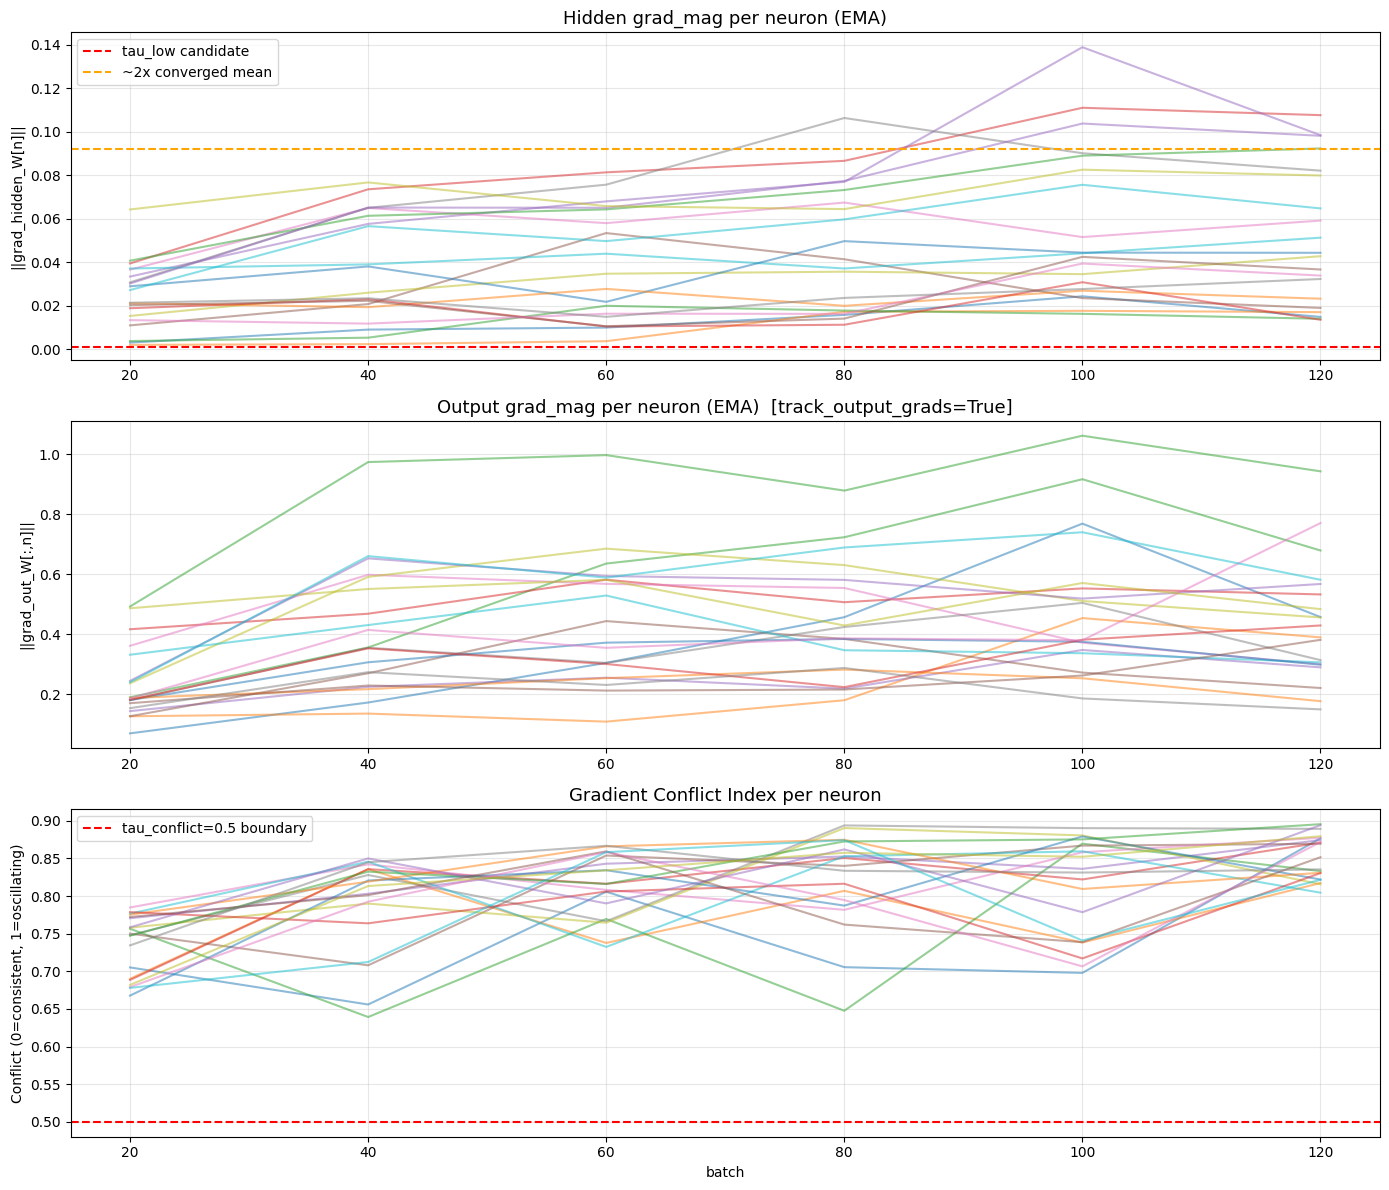

=== Diagnostic Summary (last 10 checks) ===
  hidden grad_mag  | mean=0.04251  p10=0.01165  p70=0.05828  max=0.13887
  -> tau_low candidate  : 0.01165  (p10 of converged neurons)
  -> tau_high_abs cand. : 0.05828  (p70 = top 30% = struggling)
  conflict         | mean=0.80498  fraction>=0.5: 1.00


In [69]:
# ── DIAGNOSTIC: train on T1 only, plot per-neuron metrics ────────────
# Use this to calibrate tau_low and tau_high_abs before the full run.

diag_net = DynamicBrain(input_dim=3072, seed_neurons=20).to(device)
diag_opt = torch.optim.Adam(diag_net.parameters(), lr=0.003)
diag_crit = nn.CrossEntropyLoss()

diag_mon = NeuronHealthMonitor(
    num_neurons=20, device=device,
    alpha=0.05, check_interval=20, patience=99,  # patience=99: never actually freeze
    min_age=10, tau_low=1e-4, tau_high_mode='percentile', tau_high_pct=0.70,
    tau_conflict=0.5, track_output_grads=True
)

X_t1, y_t1 = tasks_train[0]
active_classes = [0, 1]
diag_logs = []

for epoch in range(4):
    for i in range(0, X_t1.size(0), 64):
        bx = X_t1[i:i+64].to(device)
        by = y_t1[i:i+64].to(device)
        if bx.size(0) < 16:
            continue

        diag_net.zero_grad()
        pred = diag_net(bx)
        lm   = torch.ones_like(pred, dtype=torch.bool)
        lm[:, active_classes] = False
        pred[lm] = -float('inf')
        loss = diag_crit(pred, by)
        loss.backward()

        hidden_grad = diag_net.hidden_W.grad.clone()
        out_grad    = diag_net.out_W.grad.clone()

        diag_mon.pre_step(diag_net)
        diag_net.zero_frozen_grads()
        diag_opt.step()
        diag_mon.post_step(diag_net, hidden_grad, out_grad)

        if diag_mon.batch_no % 20 == 0:
            _, _, snap = diag_mon.check_health(diag_net)
            diag_logs.append(snap)

batches = [s['batch'] for s in diag_logs]
gm_arr  = np.array([s['grad_mag'] for s in diag_logs])       # (steps, neurons)
og_arr  = np.array([s['out_grad_mag'] for s in diag_logs])
cf_arr  = np.array([s['conflict'] for s in diag_logs])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: hidden grad_mag per neuron
for n in range(20):
    axes[0].plot(batches, gm_arr[:, n], alpha=0.5)
axes[0].set_title('Hidden grad_mag per neuron (EMA)', fontsize=13)
axes[0].set_ylabel('||grad_hidden_W[n]||')
axes[0].axhline(0.001, color='red',    linestyle='--', label='tau_low candidate')
axes[0].axhline(gm_arr[-5:, :].mean()*2, color='orange',
                linestyle='--', label='~2x converged mean')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2: output grad_mag per neuron
for n in range(20):
    axes[1].plot(batches, og_arr[:, n], alpha=0.5)
axes[1].set_title('Output grad_mag per neuron (EMA)  [track_output_grads=True]', fontsize=13)
axes[1].set_ylabel('||grad_out_W[:,n]||')
axes[1].grid(alpha=0.3)

# Panel 3: SI contribution per neuron
for n in range(20):
    axes[2].plot(batches, cf_arr[:, n], alpha=0.5)
axes[2].axhline(0.5, color='red', linestyle='--', label='tau_conflict=0.5 boundary')
axes[2].set_title('Gradient Conflict Index per neuron', fontsize=13)
axes[2].set_ylabel('Conflict (0=consistent, 1=oscillating)')
axes[2].set_xlabel('batch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nsi_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics to guide threshold selection
late = gm_arr[-10:, :]   # last 10 checkpoints
print("=== Diagnostic Summary (last 10 checks) ===")
print(f"  hidden grad_mag  | mean={late.mean():.5f}  p10={np.percentile(late,10):.5f}  p70={np.percentile(late,70):.5f}  max={late.max():.5f}")
print(f"  -> tau_low candidate  : {np.percentile(late,10):.5f}  (p10 of converged neurons)")
print(f"  -> tau_high_abs cand. : {np.percentile(late,70):.5f}  (p70 = top 30% = struggling)")
print(f"  conflict         | mean={cf_arr[-10:].mean():.5f}  fraction>=0.5: {(cf_arr[-10:]>=0.5).mean():.2f}")


## Step 2 — Full NSI Training

In [70]:
# ── FULL TRAINING: NSI Dynamic Brain ─────────────────────────────────
# Run the diagnostic cell first to calibrate tau_low / tau_high_abs!
# Then adjust the config below accordingly.

CFG = dict(
    seed_neurons    = 10,
    lr              = 0.003,
    epochs_per_task = 50,
    batch_size      = 64,
    # NeuronHealthMonitor settings
    alpha           = 0.05,
    check_interval  = 20,
    patience        = 3,
    min_age         = 40,
    tau_low         = 0.025,        # UPDATED from diagnostic        # calibrate from diagnostic
    tau_high_mode   = 'percentile', # 'percentile' or 'absolute'
    tau_high_pct    = 0.70,         # used when mode='percentile'
    tau_high_abs    = None,         # used when mode='absolute' (set from diagnostic)
    tau_conflict    = 0.5,          # NEW: conflict threshold
    track_output_grads = True,
)

net  = DynamicBrain(input_dim=3072, seed_neurons=CFG['seed_neurons'], k_frozen=5, k_plastic=5).to(device)
opt  = torch.optim.Adam(net.parameters(), lr=CFG['lr'])
crit = nn.CrossEntropyLoss()

mon = NeuronHealthMonitor(
    num_neurons        = CFG['seed_neurons'],
    device             = device,
    alpha              = CFG['alpha'],
    check_interval     = CFG['check_interval'],
    patience           = CFG['patience'],
    min_age            = CFG['min_age'],
    tau_low            = CFG['tau_low'],
    tau_high_mode      = CFG['tau_high_mode'],
    tau_high_pct       = CFG['tau_high_pct'],
    tau_high_abs       = CFG['tau_high_abs'],
    tau_conflict       = CFG['tau_conflict'],
    track_output_grads = CFG['track_output_grads'],
)

dynamic_accs   = []
growth_events  = []    # [(batch, freeze_indices, n_sprout)]
total_batches  = 0

print("Training NSI Dynamic Brain on Split CIFAR-10...")
for task_idx, (X_tr_, y_tr_) in enumerate(tasks_train):
    print(f"\n--- Task {task_idx+1}/5  ({task_names[task_idx]}) ---")
    active_classes = [task_idx*2, task_idx*2+1]

    for epoch in range(CFG['epochs_per_task']):
        for i in range(0, X_tr_.size(0), CFG['batch_size']):
            bx = X_tr_[i:i+CFG['batch_size']].to(device)
            by = y_tr_[i:i+CFG['batch_size']].to(device)
            if bx.size(0) < 16:
                continue

            # Forward
            net.zero_grad()
            pred = net(bx)
            lm   = torch.ones_like(pred, dtype=torch.bool)
            lm[:, active_classes] = False
            pred[lm] = -float('inf')
            loss = crit(pred, by)
            loss.backward()

            # Capture grads BEFORE optimizer step
            hg = net.hidden_W.grad.clone()
            og = net.out_W.grad.clone() if CFG['track_output_grads'] else None

            # Snapshot weights, zero frozen, step
            mon.pre_step(net)
            net.zero_frozen_grads()
            opt.step()
            mon.post_step(net, hg, og)

            # Periodic health check
            if mon.batch_no % CFG['check_interval'] == 0:
                to_freeze, n_sprout, snap = mon.check_health(net)

                if to_freeze or n_sprout > 0:
                    n_frozen_total = sum(1 for s in net.neuron_states if s=='FROZEN')
                    print(f"  Batch {total_batches:04d} | "
                          f"freeze {len(to_freeze)} | "
                          f"sprout {n_sprout} | "
                          f"total {net.active_neurons+n_sprout} neurons")
                    net.grow_and_freeze(to_freeze, n_sprout)
                    mon.expand(n_sprout)
                    opt = torch.optim.Adam(net.parameters(), lr=CFG['lr'])
                    growth_events.append((total_batches, to_freeze, n_sprout))

            total_batches += 1

    accs = evaluate(net, tasks_test, task_idx)
    dynamic_accs.append(accs)
    n_frozen  = sum(1 for s in net.neuron_states if s=='FROZEN')
    n_plastic = sum(1 for s in net.neuron_states if s=='PLASTIC')
    print(f"End of Task {task_idx+1} | frozen={n_frozen} plastic={n_plastic} total={net.active_neurons}")
    for j, a in enumerate(accs):
        print(f"  {task_names[j]}: {a*100:.1f}%")

print(f"\nFinal: {net.active_neurons} neurons  ({sum(1 for s in net.neuron_states if s=='FROZEN')} frozen)")
print(f"Growth events: {len(growth_events)}")


Training NSI Dynamic Brain on Split CIFAR-10...

--- Task 1/5  (T1:Airplane/Auto) ---
  Batch 0079 | freeze 2 | sprout 2 | total 12 neurons
  Batch 0119 | freeze 1 | sprout 1 | total 13 neurons
  Batch 0159 | freeze 2 | sprout 1 | total 14 neurons
  Batch 0179 | freeze 2 | sprout 2 | total 16 neurons
  Batch 0199 | freeze 1 | sprout 0 | total 16 neurons
  Batch 0219 | freeze 1 | sprout 1 | total 17 neurons
  Batch 0259 | freeze 3 | sprout 1 | total 18 neurons
  Batch 0279 | freeze 1 | sprout 1 | total 19 neurons
  Batch 0299 | freeze 2 | sprout 1 | total 20 neurons
  Batch 0339 | freeze 2 | sprout 2 | total 22 neurons
  Batch 0359 | freeze 1 | sprout 1 | total 23 neurons
  Batch 0379 | freeze 1 | sprout 1 | total 24 neurons
  Batch 0419 | freeze 2 | sprout 2 | total 26 neurons
  Batch 0439 | freeze 1 | sprout 1 | total 27 neurons
  Batch 0459 | freeze 2 | sprout 2 | total 29 neurons
  Batch 0499 | freeze 2 | sprout 2 | total 31 neurons
  Batch 0539 | freeze 3 | sprout 3 | total 34 neur

## Step 3 — Analysis & Insight Plots

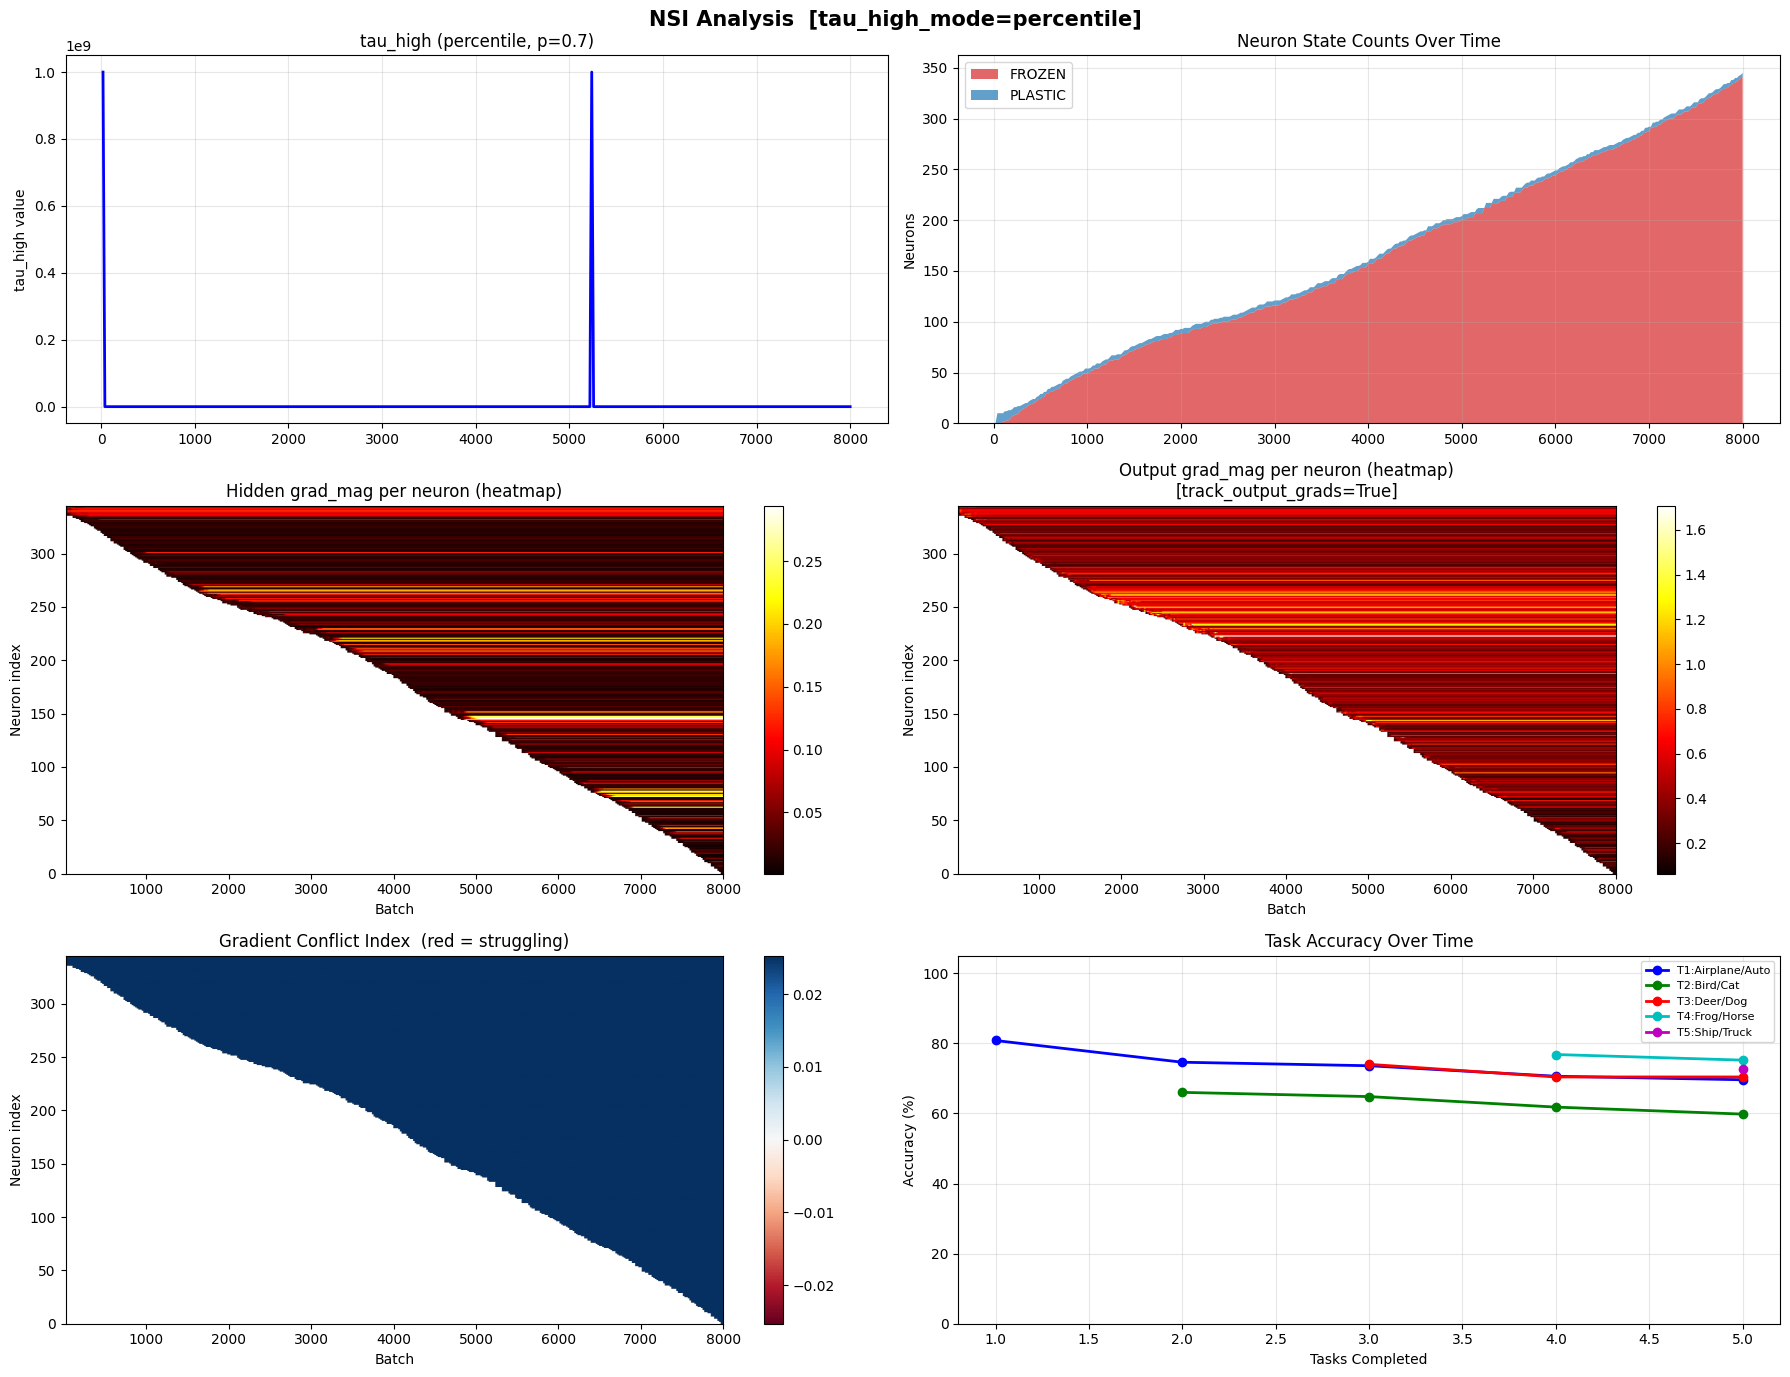


=== Output vs Hidden Grad Correlation ===

=== tau_high_mode='percentile' summary ===
  tau_high range: [0.00766, 1000000000.00000]
  Total growth events: 231
  Final neuron count: 347


In [71]:
# ── ANALYSIS: tau_high_mode comparison + output vs hidden grads ───────
logs = mon.log
if not logs:
    print("No logs yet — run the training cell first.")
else:
    batches  = [s['batch']     for s in logs]
    tau_vals = [s['tau_high']  for s in logs]
    n_frozen = [s['n_frozen']  for s in logs]
    n_plastic= [s['n_plastic'] for s in logs]
    n_sprout = [s['n_sprout_now'] for s in logs]
    n_freeze = [s['n_freeze_now'] for s in logs]

    # Pad jagged arrays (neuron count grows over time) to max length with NaN
    max_n = max(len(s['grad_mag']) for s in logs)
    def _pad(lst):
        return lst + [float('nan')] * (max_n - len(lst))
    gm_arr = np.array([_pad(s['grad_mag'])     for s in logs])
    og_arr = np.array([_pad(s['out_grad_mag']) for s in logs])
    cf_arr = np.array([_pad(s['conflict']) for s in logs])

    fig, axes = plt.subplots(3, 2, figsize=(18, 14))
    fig.suptitle(f"NSI Analysis  [tau_high_mode={CFG['tau_high_mode']}]",
                 fontsize=15, fontweight='bold')

    # P1: tau_high evolution
    ax = axes[0, 0]
    ax.plot(batches, tau_vals, 'b-', linewidth=2)
    if CFG['tau_high_mode'] == 'percentile':
        ax.set_title(f"tau_high (percentile, p={CFG['tau_high_pct']})")
    else:
        ax.axhline(CFG['tau_high_abs'], color='r', linestyle='--')
        ax.set_title("tau_high (absolute, fixed)")
    ax.set_ylabel('tau_high value')
    ax.grid(alpha=0.3)

    # P2: frozen/plastic count
    ax = axes[0, 1]
    ax.stackplot(batches, n_frozen, n_plastic, labels=['FROZEN','PLASTIC'],
                 colors=['#d62728','#1f77b4'], alpha=0.7)
    ax.set_title('Neuron State Counts Over Time')
    ax.set_ylabel('Neurons')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    # P3: hidden grad_mag heatmap
    ax = axes[1, 0]
    im = ax.imshow(gm_arr.T, aspect='auto', cmap='hot',
                   extent=[batches[0], batches[-1], 0, gm_arr.shape[1]])
    plt.colorbar(im, ax=ax)
    ax.set_title('Hidden grad_mag per neuron (heatmap)')
    ax.set_ylabel('Neuron index')
    ax.set_xlabel('Batch')

    # P4: output grad_mag heatmap
    ax = axes[1, 1]
    im = ax.imshow(og_arr.T, aspect='auto', cmap='hot',
                   extent=[batches[0], batches[-1], 0, og_arr.shape[1]])
    plt.colorbar(im, ax=ax)
    ax.set_title('Output grad_mag per neuron (heatmap)\n[track_output_grads=True]')
    ax.set_ylabel('Neuron index')
    ax.set_xlabel('Batch')

    # P5: SI contribution heatmap (diverging)
    ax = axes[2, 0]
    vmax = np.abs(ct_arr).max() + 1e-8
    im = ax.imshow(cf_arr.T, aspect='auto', cmap='RdBu',
                   vmin=-vmax, vmax=vmax,
                   extent=[batches[0], batches[-1], 0, cf_arr.shape[1]])
    plt.colorbar(im, ax=ax)
    ax.set_title('Gradient Conflict Index  (red = struggling)')
    ax.set_ylabel('Neuron index')
    ax.set_xlabel('Batch')

    # P6: Task accuracy curves
    ax = axes[2, 1]
    colors = ['b','g','r','c','m']
    for tid in range(5):
        xs, ys = [], []
        for step, accs in enumerate(dynamic_accs):
            if tid < len(accs):
                xs.append(step+1); ys.append(accs[tid]*100)
        if xs:
            ax.plot(xs, ys, f'{colors[tid]}o-', label=task_names[tid], linewidth=2)
    ax.set_ylim(0, 105)
    ax.set_title('Task Accuracy Over Time')
    ax.set_xlabel('Tasks Completed')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('nsi_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Correlation: does output grad predict forgetting?
    print("\n=== Output vs Hidden Grad Correlation ===")
    late_h = gm_arr[-10:].mean(0)   # late hidden grad per neuron
    late_o = og_arr[-10:].mean(0)   # late output grad per neuron
    if late_h.std() > 0 and late_o.std() > 0:
        corr = np.corrcoef(late_h, late_o)[0,1]
        print(f"  Pearson correlation (hidden vs output grad_mag): {corr:.3f}")
        print("  -> Close to 1.0: output grads add no new info (active-class masking works)")
        print("  -> Far from 1.0: output grads carry different signal (worth tracking)")
    
    print(f"\n=== tau_high_mode='{CFG['tau_high_mode']}' summary ===")
    print(f"  tau_high range: [{min(tau_vals):.5f}, {max(tau_vals):.5f}]")
    print(f"  Total growth events: {len(growth_events)}")
    print(f"  Final neuron count: {net.active_neurons}")


## Step 4 — Experiment: percentile vs absolute tau_high

In [72]:
# ── EXPERIMENT: run percentile mode vs absolute mode side-by-side ────
# Set tau_high_abs from diagnostic cell first, then run this.
# This lets you directly compare the two tau_high strategies.

def run_experiment(tau_high_mode, tau_high_pct=0.70, tau_high_abs=None, label=''):
    net_  = DynamicBrain(input_dim=3072, seed_neurons=10).to(device)
    opt_  = torch.optim.Adam(net_.parameters(), lr=0.003)
    crit_ = nn.CrossEntropyLoss()
    mon_  = NeuronHealthMonitor(
        num_neurons=10, device=device,
        alpha=0.05, check_interval=20, patience=3, min_age=40,
        tau_low=0.001,
        tau_high_mode=tau_high_mode,
        tau_high_pct=tau_high_pct,
        tau_high_abs=tau_high_abs,
        tau_conflict=0.5,
        track_output_grads=True,
    )
    accs_hist = []

    for task_idx, (Xtr_, ytr_) in enumerate(tasks_train):
        active_classes = [task_idx*2, task_idx*2+1]
        for epoch in range(3):
            for i in range(0, Xtr_.size(0), 64):
                bx = Xtr_[i:i+64].to(device); by = ytr_[i:i+64].to(device)
                if bx.size(0) < 16: continue
                net_.zero_grad()
                pred = net_(bx)
                lm   = torch.ones_like(pred, dtype=torch.bool)
                lm[:, active_classes] = False
                pred[lm] = -float('inf')
                loss = crit_(pred, by)
                loss.backward()
                hg = net_.hidden_W.grad.clone()
                og = net_.out_W.grad.clone()
                mon_.pre_step(net_)
                net_.zero_frozen_grads()
                opt_.step()
                mon_.post_step(net_, hg, og)
                if mon_.batch_no % 20 == 0:
                    to_freeze, n_sprout, _ = mon_.check_health(net_)
                    if to_freeze or n_sprout > 0:
                        net_.grow_and_freeze(to_freeze, n_sprout)
                        mon_.expand(n_sprout)
                        opt_ = torch.optim.Adam(net_.parameters(), lr=0.003)
        accs_hist.append(evaluate(net_, tasks_test, task_idx))

    print(f"[{label}] final neurons={net_.active_neurons}  "
          f"frozen={sum(1 for s in net_.neuron_states if s=='FROZEN')}")
    return accs_hist, mon_.log

print("Run with:")
print("  accs_pct, log_pct = run_experiment('percentile', tau_high_pct=0.70, label='percentile-p70')")
print("  accs_abs, log_abs = run_experiment('absolute',   tau_high_abs=<from diagnostic>, label='absolute')")
print()
print("Then compare accs_pct vs accs_abs on a plot.")


Run with:
  accs_pct, log_pct = run_experiment('percentile', tau_high_pct=0.70, label='percentile-p70')
  accs_abs, log_abs = run_experiment('absolute',   tau_high_abs=<from diagnostic>, label='absolute')

Then compare accs_pct vs accs_abs on a plot.


## Step 5 — Hyperparameter Grid Search
Sweep over `seed_neurons`, `k_frozen`, and `k_plastic` to find the optimal balance between high accuracy and small network size.

In [73]:
# ─── GRID SEARCH: Find the perfect Brain architecture ────
# This will test multiple combinations of seed_neurons, k_frozen, and k_plastic.
import time
import pandas as pd
from IPython.display import display

def run_sweep(seed, kf, kp, epochs=3):
    print(f"\n--- Testing Config: seed={seed}, k_frozen={kf}, k_plastic={kp} ---")
    
    # We use a slightly simplified monitor for speed
    net_  = DynamicBrain(input_dim=3072, seed_neurons=seed, k_frozen=kf, k_plastic=kp).to(device)
    opt_  = torch.optim.Adam(net_.parameters(), lr=0.003)
    crit_ = nn.CrossEntropyLoss()
    
    mon_  = NeuronHealthMonitor(
        num_neurons=seed, device=device,
        alpha=0.05, check_interval=20, patience=3, min_age=40,
        tau_low=0.025,
        tau_high_mode='percentile',
        tau_high_pct=0.70,
        tau_conflict=0.5,
        track_output_grads=False,
    )
    
    t0 = time.time()
    for task_idx, (Xtr_, ytr_) in enumerate(tasks_train):
        active_classes = [task_idx*2, task_idx*2+1]
        for epoch in range(epochs):
            for i in range(0, Xtr_.size(0), 64):
                bx = Xtr_[i:i+64].to(device); by = ytr_[i:i+64].to(device)
                if bx.size(0) < 16: continue
                
                net_.zero_grad()
                pred = net_(bx)
                lm   = torch.ones_like(pred, dtype=torch.bool)
                lm[:, active_classes] = False
                pred[lm] = -float('inf')
                
                loss = crit_(pred, by)
                loss.backward()
                
                hg = net_.hidden_W.grad.clone()
                mon_.pre_step(net_)
                net_.zero_frozen_grads()
                opt_.step()
                mon_.post_step(net_, hg, None)
                
                if mon_.batch_no % 20 == 0:
                    to_freeze, n_sprout, _ = mon_.check_health(net_)
                    if to_freeze or n_sprout > 0:
                        net_.grow_and_freeze(to_freeze, n_sprout)
                        mon_.expand(n_sprout)
                        opt_ = torch.optim.Adam(net_.parameters(), lr=0.003)

    # Evaluate on all tasks
    accs = evaluate(net_, tasks_test, 4)  # evaluate all 5 tasks (index 4)
    avg_acc = sum(accs) / 5.0
    
    t1 = time.time()
    n_frozen = sum(1 for s in net_.neuron_states if s=='FROZEN')
    print(f"Result: Avg Acc = {avg_acc*100:.1f}% | Total Neurons = {net_.active_neurons} | Time = {t1-t0:.1f}s")
    
    return {
        'seed_neurons': seed,
        'k_frozen': kf,
        'k_plastic': kp,
        'final_neurons': net_.active_neurons,
        'frozen_neurons': n_frozen,
        'avg_accuracy (%)': round(avg_acc * 100, 2),
        'time (s)': round(t1 - t0, 1)
    }

# Define the grid of parameters to test
configs_to_test = [
    {'seed': 5,  'kf': 5,  'kp': 3},   # Tiny Brain
    {'seed': 5,  'kf': 5,  'kp': 5},
    {'seed': 10, 'kf': 10, 'kp': 5},   # Standard Brain
    {'seed': 10, 'kf': 5,  'kp': 5},   # Standard with tight kWTA bottleneck
    {'seed': 20, 'kf': 15, 'kp': 5},   # Wide Brain
    {'seed': 20, 'kf': 10, 'kp': 10},  # Wide Brain with high plasticity
]

results = []
# We use 3 epochs for the sweep so it finishes in a few minutes
for c in configs_to_test:
    res = run_sweep(c['seed'], c['kf'], c['kp'], epochs=3)
    results.append(res)

print("\n\n======= SWEEP LEADERBOARD =======")
df = pd.DataFrame(results)
# Sort by highest accuracy, then by smallest network size
df = df.sort_values(by=['avg_accuracy (%)', 'final_neurons'], ascending=[False, True])
display(df)



--- Testing Config: seed=5, k_frozen=5, k_plastic=3 ---
Result: Avg Acc = 74.2% | Total Neurons = 12 | Time = 1.7s

--- Testing Config: seed=5, k_frozen=5, k_plastic=5 ---
Result: Avg Acc = 71.0% | Total Neurons = 17 | Time = 1.8s

--- Testing Config: seed=10, k_frozen=10, k_plastic=5 ---
Result: Avg Acc = 72.4% | Total Neurons = 26 | Time = 2.1s

--- Testing Config: seed=10, k_frozen=5, k_plastic=5 ---
Result: Avg Acc = 72.2% | Total Neurons = 24 | Time = 2.2s

--- Testing Config: seed=20, k_frozen=15, k_plastic=5 ---
Result: Avg Acc = 71.4% | Total Neurons = 39 | Time = 3.3s

--- Testing Config: seed=20, k_frozen=10, k_plastic=10 ---
Result: Avg Acc = 71.5% | Total Neurons = 48 | Time = 2.8s


======= SWEEP LEADERBOARD =======


,seed_neurons,k_frozen,k_plastic,final_neurons,frozen_neurons,avg_accuracy (%),time (s)
0,5,5,3,12,8,74.24,1.7
2,10,10,5,26,21,72.36,2.1
3,10,5,5,24,18,72.16,2.2
5,20,10,10,48,38,71.52,2.8
4,20,15,5,39,34,71.44,3.3
1,5,5,5,17,12,71.04,1.8
